<a href="https://colab.research.google.com/github/hkumi/Be12pp-simulation/blob/main/Project_8_Gold_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Importing all dependencies

In [40]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import accuracy_score
from xgboost import XGBRegressor
from sklearn import metrics

In [3]:
gold_dataset = pd.read_csv("/content/gld_price_data.csv")

#Understanding the data

In [39]:
gold_dataset.head()

,Date,SPX,GLD,USO,SLV,EUR/USD
0,1/2/2008,1447.160034,84.860001,78.470001,15.180,1.471692
1,1/3/2008,1447.160034,85.570000,78.370003,15.285,1.474491
2,1/4/2008,1411.630005,85.129997,77.309998,15.167,1.475492
3,1/7/2008,1416.180054,84.769997,75.500000,15.053,1.468299
4,1/8/2008,1390.189941,86.779999,76.059998,15.590,1.557099


In [5]:
gold_dataset.shape

(2290, 6)

In [6]:
gold_dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2290 entries, 0 to 2289
Data columns (total 6 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Date     2290 non-null   object 
 1   SPX      2290 non-null   float64
 2   GLD      2290 non-null   float64
 3   USO      2290 non-null   float64
 4   SLV      2290 non-null   float64
 5   EUR/USD  2290 non-null   float64
dtypes: float64(5), object(1)
memory usage: 107.5+ KB


In [7]:
gold_dataset.describe()

,SPX,GLD,USO,SLV,EUR/USD
count,2290.000000,2290.000000,2290.000000,2290.000000,2290.000000
mean,1654.315776,122.732875,31.842221,20.084997,1.283653
std,519.111540,23.283346,19.523517,7.092566,0.131547
min,676.530029,70.000000,7.960000,8.850000,1.039047
25%,1239.874969,109.725000,14.380000,15.570000,1.171313
50%,1551.434998,120.580002,33.869999,17.268500,1.303297
75%,2073.010070,132.840004,37.827501,22.882500,1.369971
max,2872.870117,184.589996,117.480003,47.259998,1.598798


In [8]:
gold_dataset.isnull().sum() #to find the missing numbers

,0
Date,0
SPX,0
GLD,0
USO,0
SLV,0
EUR/USD,0


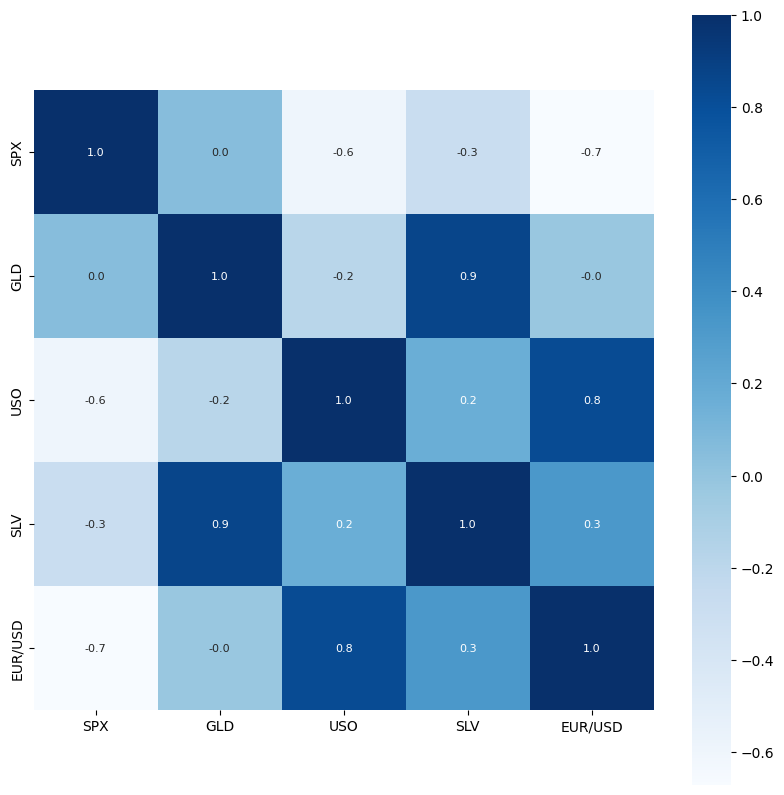

In [48]:
correlation = gold_dataset.corr(numeric_only=True)
# Plot the heatmap
plt.figure(figsize=(10, 10))
sns.heatmap(correlation, cbar=True, square=True, fmt=".1f", annot=True, annot_kws={"size": 8}, cmap="Blues")
plt.show()

<Axes: xlabel='GLD', ylabel='Count'>

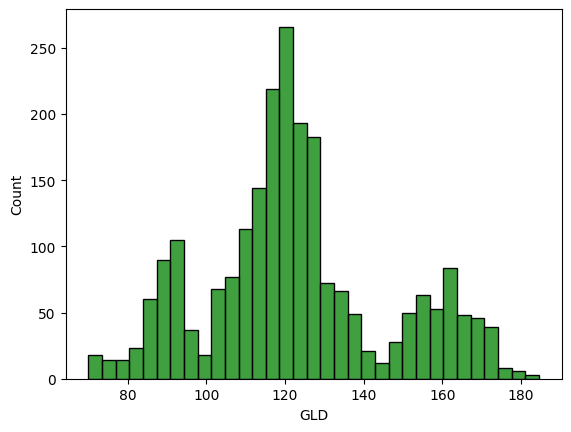

In [49]:
sns.histplot(gold_dataset['GLD'],color="green")

#plotting and seeing the relationshi between other data and the price

In [50]:
# separating the data & label
X = gold_dataset.drop(columns=['Date',"GLD"], axis=1)
Y = gold_dataset['GLD']

In [51]:
print(X)

              SPX        USO      SLV   EUR/USD
0     1447.160034  78.470001  15.1800  1.471692
1     1447.160034  78.370003  15.2850  1.474491
2     1411.630005  77.309998  15.1670  1.475492
3     1416.180054  75.500000  15.0530  1.468299
4     1390.189941  76.059998  15.5900  1.557099
...           ...        ...      ...       ...
2285  2671.919922  14.060000  15.5100  1.186789
2286  2697.790039  14.370000  15.5300  1.184722
2287  2723.070068  14.410000  15.7400  1.191753
2288  2730.129883  14.380000  15.5600  1.193118
2289  2725.780029  14.405800  15.4542  1.182033

[2290 rows x 4 columns]


In [52]:
print(Y)

0        84.860001
1        85.570000
2        85.129997
3        84.769997
4        86.779999
           ...    
2285    124.589996
2286    124.330002
2287    125.180000
2288    124.489998
2289    122.543800
Name: GLD, Length: 2290, dtype: float64


In [53]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size = 0.2, random_state=2)

In [54]:
print(X_train.shape,X_test.shape)

(1832, 4) (458, 4)


In [55]:
model = RandomForestRegressor()

In [56]:
model.fit(X_train,Y_train)

RandomForestRegressor()

In [57]:
#prediction on the training data
X_train_prediction = model.predict(X_train)
#R squared error.
score_1 = metrics.r2_score(Y_train,X_train_prediction)
#Mean Absolute Error
score_2 = metrics.mean_absolute_error(Y_train,X_train_prediction)
#this values should be closer to 1 and 0 respectively
print(score_1)
print(score_2)

0.9984522163027905
0.48731876753274894


In [58]:
#Accuracy on test data
X_test_prediction = model.predict(X_test)

In [59]:
#R squared error.
test_score_1 = metrics.r2_score(Y_test,X_test_prediction)
#Mean Absolute Error
test_score_2 = metrics.mean_absolute_error(Y_test,X_test_prediction)
#this values should be closer to 1 and 0 respectively
print(test_score_1)
print(test_score_2)

0.9891307780169927
1.3199842833187743


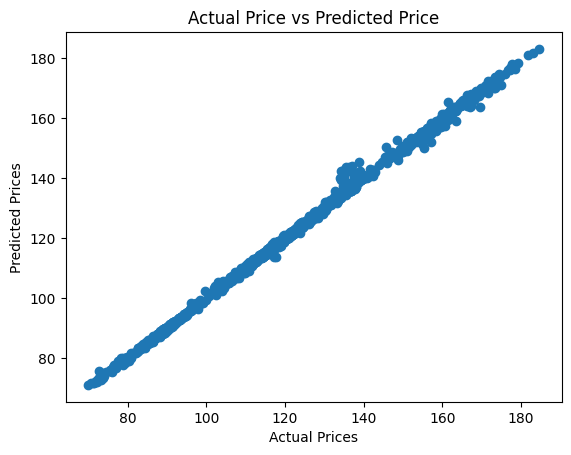

In [60]:
plt.scatter(Y_train,X_train_prediction)
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual Price vs Predicted Price")
plt.show()

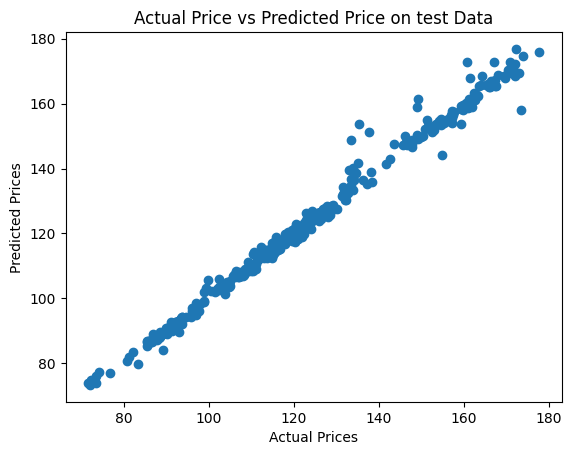

In [65]:
Y_test=list(Y_test)
plt.scatter(Y_test,X_test_prediction)

plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual Price vs Predicted Price on test Data")
plt.show()

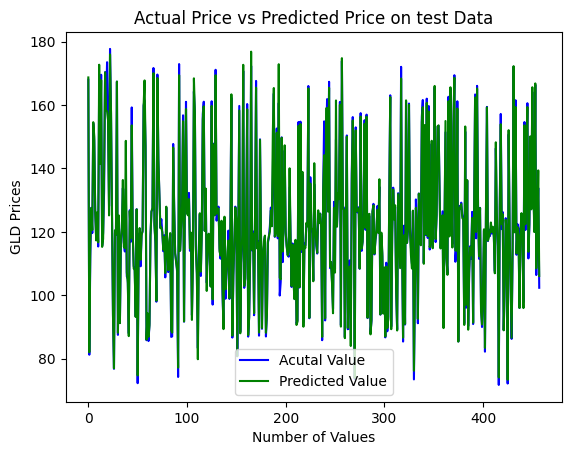

In [66]:
plt.plot(Y_test,color="blue",label = "Acutal Value")
plt.plot(X_test_prediction,color="green",label = "Predicted Value")
plt.title("Actual Price vs Predicted Price on test Data")
plt.xlabel("Number of Values")
plt.ylabel("GLD Prices")
plt.legend()
plt.show()

#Making a predictive system

In [61]:
input_data = (1447.160034,	78.470001,	15.180,	1.471692)

#changing the data type into numpy array

input_data_as_numpy_array = np.asarray(input_data)
#reshape the numpy array as we are predicting for one instance
input_data_reshape = input_data_as_numpy_array.reshape(1,-1)
prediction = model.predict(input_data_reshape)
print("this price of this gold can be  :",  prediction ,"dollars")

this price of this gold can be  : [85.00480035] dollars


/usr/local/lib/python3.10/dist-packages/sklearn/base.py:465: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
